In [2]:
from qiskit import *

In [3]:
import qiskit

#returns a list with the indexes of all qubits in qregs
def get_qubits(qc: qiskit.QuantumCircuit, qregs: list[qiskit.QuantumRegister]) -> list[int]:
    """Find the index location in the circuit of all qubits from all given registers.
    
    Args:
        qc (QuantumCircuit): The quantum circuit from wich the registers will be searched.
        qregs (list[QuantumRegister]): A list of quantum registers from qc, order does matter.

    Returns:
        indexList(list[int]): A list containing the interger indexes of all qubits from given registers.
    
    Examples:
        Getting the qubits from 2 registers::

            from qiskit import *
            
            a = QuantumRegister(2, "a")

            b = QuantumRegister(2, "b")

            c = QuantumRegister(2, "c")

            qc = QuantumCircuit(a, b, c)

            #Get qubits from c and a
            
            bitIndexes = get_qubits(qc, [c, a])

            #bitIndexes will look like this: [4,5,0,1]
    
    """
    bits = []
    for qreg in qregs:
        n = qc.find_bit(qreg[0]).index
        bits.extend(list(range(n, n+qreg.size)))
    return bits

#applies a not in all bits of a given register acconding to control bit
def cx_reg(num_qubits: int) -> qiskit.QuantumCircuit:
    reg = qiskit.QuantumRegister(num_qubits, name="reg")
    c = qiskit.QuantumRegister(1, name="c")
    qc = qiskit.QuantumCircuit(reg,c)
    qc.name = "cx-reg"
    for qubit in reg:
        qc.cx(c[0], qubit)
    return qc

#depending on the control bit state, copies n qubit register into another
def c_copy(num_qubits: int) -> qiskit.QuantumCircuit:
    """Depending on control-qubit state, copies n-qubit register into another.

    The circuit has the following effect when control-qubit is positive:

    |a,0> -> |a,a>
    
    Args:
        num_qubits (int): the number of qubits in register.

    Returns:
        quantum_curcuit(QuantumCircuit): A quantum circuit defining the operation.
    
    Exemple:
        c_copy(2)

        c:  --●--●---
        
        o0: --●--●---
              
        o1: --|--|---
              
        t0: --⨁-|---
               
        t1: -----⨁---
    """
    c = qiskit.QuantumRegister(1, name="c")
    origin = qiskit.QuantumRegister(num_qubits, name="o")
    target = qiskit.QuantumRegister(num_qubits, name="t")
    quantum_circuit = qiskit.QuantumCircuit(c, origin, target)
    quantum_circuit.name = "c-copy"
    for i in range(num_qubits):
        quantum_circuit.ccx(c[0], origin[i], target[i])
    return quantum_circuit

#if control qubit is 0, zeroes out N, N is given and computed classically, else does nothing
#if N is initialized at 0, sets 0 to N
def c_set_reset(num_qubits: int, N: int) -> qiskit.QuantumCircuit:
    """Depending on control-qubit state, resets register to `0` or does nothing
    
    The circuit has the following effect: 

    c = 0
    -
    |num> -> |0>
    
    |0> -> |num>
    
    c = 1
    -
    |num> -> |num>

    .. note::
        In particular, this circuits control-bit is controlled _negatively_.
        Keep that in mind if you want to use it and make sure to do the proper 
        not opperations to have it positively controlled.
        
        Moreover, :attr:`N` should have no more than :attr:`num_qubits` in its binary representation.

    Args:
        num_qubits (int): the number of qubits in register.
        N (int): the number in wich the register should be set/reseted to.

    Returns:
        quantum_curcuit(QuantumCircuit): A quantum circuit defining the operation.
    """   
    bit_string = bin(N)[2:]
    bit_string = bit_string.rjust(num_qubits, "0")
    circ_n = qiskit.QuantumRegister(num_qubits, name="N")
    c = qiskit.QuantumRegister(1, name="c")
    quantum_circuit = qiskit.QuantumCircuit(c, circ_n)
    quantum_circuit.name = "c-set-reset"
    quantum_circuit.x(c[0])
    for bit in range(len(bit_string)):
        if bit_string[bit] == "1":
            quantum_circuit.cx(c[0], circ_n[num_qubits-bit-1])
    quantum_circuit.x(c[0])
            
    return quantum_circuit


def set_reset_to(num_qubits: int, number: int) -> qiskit.QuantumCircuit:
    """Sets register to :attr:`number` or resets it to `0` if register contains :attr:`number`

    The circuit has the following effect: 

    |0> -> |number>

    |number> -> |0>
    
    .. note::
        :attr:`number` should have no more than :attr:`num_qubits` in its binary representation.
    
    Args:
        num_qubits (int): the number of qubits in register.
        number (int): the number in wich the register should be set/reseted to.

    Returns:
        quantum_curcuit(QuantumCircuit): A quantum circuit defining the operation.
    """
    num = qiskit.QuantumRegister(num_qubits, name="num")
    quantum_curcuit = qiskit.QuantumCircuit(num)
    quantum_curcuit.name = "set-reset"
    bit_string = bin(number)[2:]
    bit_string = bit_string.rjust(num_qubits, "0")
    for bit in range(len(bit_string)):
        if bit_string[bit] == "1":
            quantum_curcuit.x(num[num_qubits-bit-1])
    return quantum_curcuit


def cc_set_reset_to_num(num_qubits: int, num: int) -> qiskit.QuantumCircuit:
    """Depending on control-qubits state, sets register to :attr:`num` or resets it to `0` if register contains :attr:`num`

    The circuit has the following effect on register when both control-qubits are positive: 

    |0> -> |num>

    |num> -> |0>

    .. note::
        :attr:`num` should have no more than :attr:`num_qubits` in its binary representation.
      
    Args:
        num_qubtis (int): the number of qubits in register.
        num (int): the number in wich the register should be set/reseted to.

    Returns:
        quantum_curcuit(QuantumCircuit): A quantum circuit defining the operation.
    """
    c = qiskit.QuantumRegister(1, name="c")
    xi = qiskit.QuantumRegister(1, name="xi")
    target = qiskit.QuantumRegister(num_qubits, name="t")
    quantum_circuit = qiskit.QuantumCircuit(c, xi, target)
    quantum_circuit.name = "cc-set-reset"
    bit_string = bin(num)[2:]
    bit_string = bit_string.rjust(num_qubits, "0")
    for bit in range(len(bit_string)):
        if bit_string[bit] == "1":
            quantum_circuit.ccx(c[0], xi[0], target[num_qubits-bit-1])
    return quantum_circuit

#swaps two registers
def swapper(num_qubits: int) -> qiskit.QuantumCircuit:
    """Swaps bits from two n-qubit registers.

    Defines the operation |x,y> -> |y,x>

    Args:
        num_qubits (int): number of qubits from registers

    Returns:
        quantum_circuit(QuantumCircuit): A quantum circuit defining the swap operation
    
    Example:
        swapper(2)

        x0: --x---- y0

        x1: --|-x-- y1

        y0: --x-|-- x0

        y1: ----x-- x1
    """
    x = qiskit.QuantumRegister(num_qubits, name="x")
    y = qiskit.QuantumRegister(num_qubits, name="y")
    quantum_citcuit = qiskit.QuantumCircuit(x,y)
    quantum_citcuit.name = "swapper"

    for i in range(num_qubits):
        quantum_citcuit.swap(x[i], y[i])
    return quantum_citcuit

def mod_inverse(base, exponent, mod):
    """Compute the modular inverse of base^(2^exponent) mod mod"""
    
    # Compute a^(2^i) using modular exponentiation
    value = pow(base, 2**exponent, mod)

    # Compute modular inverse using Extended Euclidean Algorithm
    def extended_gcd(a, b):
        if b == 0:
            return a, 1, 0
        g, x1, y1 = extended_gcd(b, a % b)
        return g, y1, x1 - (a // b) * y1
    
    g, inverse, _ = extended_gcd(value, mod)

    if g != 1:
        raise ValueError(f"No modular inverse exists for {value} mod {mod}")
    
    return inverse % mod

In [4]:
from qiskit import *

def qc_MAJ() -> QuantumCircuit:
    """
    
    q0 -----⨁--●-----
            |   |
    q1 --⨁-|---●-----
         |  |   |
    q2 --●--●---⨁----

    Returns:
        quantum_circuit (QuantumCircuit): the circuit implementing the operation.
    """
    quantum_circuit = QuantumCircuit(3)
    quantum_circuit.name = "MAJ"
    quantum_circuit.cx(2, 1)
    quantum_circuit.cx(2, 0)
    quantum_circuit.ccx(0, 1, 2)
    return quantum_circuit

#if argument is true, implements the 2cnot version, else, implements the 3cnot version
#check reference
def qc_UMA(two_version: bool=True) -> QuantumCircuit:
    """
    
    - 2-CNOT verison:

    q0 --●--⨁--●--
         |  |  |
    q1 --●--|--⨁--
         |  |
    q2 --⨁--●-----


    - 3-CNOT version:

    q0 ------●--●------⨁-----
             |  |      |
    q1 --⨁--⨁--●--⨁--|--⨁--
                |      |  |
    q2 ---------⨁-----●--●---


    Returns:
        quantum_circuit (QuantumCircuit): the circuit implementing the operation.
    """
    quantum_circuit = QuantumCircuit(3)
    quantum_circuit.name = "UMA"
    if two_version:
        quantum_circuit.ccx(0, 1, 2)
        quantum_circuit.cx(2, 0)
        quantum_circuit.cx(0, 1)
    else:
        quantum_circuit.x(1)
        quantum_circuit.cx(0, 1)
        quantum_circuit.ccx(0, 1, 2)
        quantum_circuit.x(1)
        quantum_circuit.cx(2, 0)
        quantum_circuit.cx(2, 1)
    return quantum_circuit


def adder_CDKM(num_qubits: int, modulo_2n: bool=False) -> QuantumCircuit:
    """

    Complexity:
    -
    For space, assuming `n` as the number of bits to encode the largest operand, we will have a total of:

    - `1` bit for carryIn/Ancilla
    - `2n` bits for operands `a` and `b`
    - If operation is not `modulo 2^n`:
        - `1` bit for carryOut

    Args:
        num_qubits (int): number of bits from operands.
        modulo_2n (bool): indicates if operation is made modulo 2^n or not.

    Returns:
        quantum_circuit (QuantumCircuit): the circuit implementing the operation.

    Reference:
    -
        A new quantum ripple-carry addition circuit. 
        Steven A. Cuccaro, Thomas G. Draper, Samuel A. Kutin, David Petrie Moulton
    """
    c = QuantumRegister(1, name="c")
    a = QuantumRegister(num_qubits, name="a")
    b = QuantumRegister(num_qubits, name="b")
    if not modulo_2n:
        z = QuantumRegister(1, name="z") 
        quantum_circuit = QuantumCircuit(c,a,b,z, name="Adder-CDKM")
    else:
        quantum_circuit = QuantumCircuit(c,a,b, name="Adder-CDKM-MOD2^n")
    
    quantum_circuit.append(qc_MAJ(), c[0:1] + b[0:1] + a[0:1])

    for i in range(1, num_qubits):
        quantum_circuit.append(qc_MAJ(), a[i-1:i] + b[i:i+1] + a[i:i+1])

    if not modulo_2n: quantum_circuit.cx(a[-1], z[0])
        
    for i in range(num_qubits-1, 0, -1):
        quantum_circuit.append(qc_UMA(), a[i-1:i] + b[i:i+1] + a[i:i+1])
        
    quantum_circuit.append(qc_UMA(), c[0:1] + b[0:1] + a[0:1])
    return quantum_circuit


def mod_adder_CDKM_VBE(num_qubits: int, N: int) -> QuantumCircuit:
    anc = QuantumRegister(1, name="anc")
    a = QuantumRegister(num_qubits, name="a")
    b = QuantumRegister(num_qubits, name="b")
    cO = QuantumRegister(1, name="cO")
    n = QuantumRegister(num_qubits, name="N")
    help = QuantumRegister(1, name="help")
    quantum_circuit = QuantumCircuit(anc, a, b, cO, n, help, name=f"AdderMod{N}-CDKM-VBE")

    quantum_circuit.append(set_reset_to(num_qubits, N), n[:])

    quantum_circuit.append(adder_CDKM(num_qubits), anc[:] + a[:] + b[:] + cO[:])
    quantum_circuit.append(adder_CDKM(num_qubits).inverse(), anc[:] + n[:] + b[:] + cO[:])

    quantum_circuit.cx(cO[0], help[0])

    quantum_circuit.append(c_set_reset(num_qubits, N), help[:] + n[:])
    quantum_circuit.append(adder_CDKM(num_qubits), anc[:] + n[:] + b[:] + cO[:])
    quantum_circuit.append(c_set_reset(num_qubits, N), help[:] + n[:])

    quantum_circuit.append(adder_CDKM(num_qubits).inverse(), anc[:] + a[:] + b[:] + cO[:])

    quantum_circuit.x(cO[0])
    quantum_circuit.cx(cO[0], help[0])
    quantum_circuit.x(cO[0])

    quantum_circuit.append(adder_CDKM(num_qubits), anc[:] + a[:] + b[:] + cO[:])

    quantum_circuit.append(set_reset_to(num_qubits, N), n[:])

    return quantum_circuit

In [5]:
#implementação do circuito de adição proposto por Vedral, Barenco e Ekert, utilizando 3n bits, onde n é número de bits de cada operando
from qiskit import *

#qc_carry function defines a 4 qubit circuit (carryIn, a, b, carryOut) sets the carry out value accondingly for the sum of a,b,carryIn
def qc_carry() -> QuantumCircuit:
    """Implements the bitwise carry operation, given the `carry in` and two bits `a` and `b`
    defines the `carry out`.

    cIn:  ------●--
                |
    a:    --●-●-|--
            | | | 
    b:    --●-⨁-●--
            |    |
    cOut: --⨁---⨁--
    
    Returns:
        quantum_circuit(QuantumCircuit): the circuit implementing the operation.
    """
    cIn = QuantumRegister(1, name="cIn")
    a = QuantumRegister(1, name="a")
    b = QuantumRegister(1, name="b")
    cOut = QuantumRegister(1, name="cOut")
    quantum_circuit = QuantumCircuit(cIn, a, b, cOut)
    quantum_circuit.name = "carry"

    quantum_circuit.ccx(1, 2, 3)
    quantum_circuit.cx(1, 2)
    quantum_circuit.ccx(0, 2, 3)

    return quantum_circuit

#qc_sum function defines a 3 qubit quantum circuit (a, b, s) and sets the value of s according to the result of the sum from a and b
def qc_sum() -> QuantumCircuit:
    """Implements the bitwise sum operation between two bits `c` and `a` and stores the result in `b`.

    c: ----●--
           | 
    a: -●--|--
        |  |
    b: -⨁-⨁--
    
    Returns:
        quantum_circuit(QuantumCircuit): the circuit implementing the operation.
    """
    c = QuantumRegister(1, name="c")
    a = QuantumRegister(1, name="a")
    b = QuantumRegister(1, name="b")
    quantum_circuit = QuantumCircuit(c, a, b)
    quantum_circuit.name = "sum"
    quantum_circuit.cx(1,2)
    quantum_circuit.cx(0,2)
    return quantum_circuit


#qc_adder funcion implements the adder circuit, (a,b) -> (a,a+b) using 3n bits, n = number of bits for each operand, operand b has an extra 0 bit to hold the final carry
#in order from least significant to most significant
#first n bits are from operand a, next n bits from b, extra bit for the last carry for b, the rest are n work bits c
#|c>|0>|b>|a>
def adder_VBE(num_qubits: int) -> QuantumCircuit:
    """Implements the circuit to sum two :attr:`n-bit` numbers.

    It works by first calculating all carry bits, applyign n carry gates taking the i-th c[i], a[i], b[i], c[i+1] as entries.

    The last carry-bit is stored in b.

    After that, using the calculated carry bits we apply n sum gates tanking c[i], a[i], b[i] as entries.

    Finally, we apply the inverse carry gates to reset the state of the c-bits to 0.

    The plain adder circuit has the following effect:

    (a,b) -> (a,a+b)

    If applied in reverse:

    (a,b) -> (a,b-a)            if b >= a

    (a,b) -> (a,2^(n+1)-(a-b))  if a > b

    
    Exemple for 2-bit sum plain adder circuit:

            -----                         -----    -----
    c0: ---|  -> |-----------------------|  <- |--|  -> |---
           |  c  |                       |  c  |  |  s  |
    a0: ---|  a  |-----------------------|  a  |--|  u  |---
           |  r  |                       |  r  |  |  m  |
    b0: ---|  r  |-----------------------|  r  |--|     |---
           |  y  |   -----       -----   |  y  |   -----
    c1: ---|     |--|  -> |-----|  -> |--|     |------------
            -----   |  c  |     |  s  |   -----
    a1:-------------|  a  |--●--|  u  |---------------------
                    |  r  |  |  |  m  |
    b1:-------------|  r  |--⨁-|     |---------------------
                    |  y  |      -----
    cO:-------------|     |---------------------------------
                     -----

    Complexity:
    -
    The network depth as well as number of gates can be described in `O(n)`.

    As for space, assuming `n` as the number of bits to encode the largest operand, we will have a total of:

    - `2n` bits for operands `a` and `b`
    - `1` bit for the final carry
    - `n` bits for other carries

    Args:
        num_qubits (int): number of bits from operands.

    Returns:
        quantum_circuit(QuantumCircuit): the circuit implementing the operation.

    Reference: 
    -
        Quantum Networks for Elementary Arithmetic Operations.
        V. Vedral, A. Barenco, A. Ekert
    """
    a = QuantumRegister(num_qubits, name="a")
    b = QuantumRegister(num_qubits, name="b")
    zero = QuantumRegister(1, name="0")
    c = QuantumRegister(num_qubits, name="c")
    quantum_circuit = QuantumCircuit(a, b, zero, c)
    quantum_circuit.name = "Adder-VBE"

    carry_circ = qc_carry()
    sum_circ = qc_sum()

    for i in range(num_qubits):
        quantum_circuit.compose(carry_circ, qubits=[2*num_qubits+1+i, i, num_qubits+i, 2*num_qubits+2+i if i != num_qubits-1 else 2*num_qubits], inplace=True)
    quantum_circuit.cx(num_qubits-1, 2*num_qubits-1)
    quantum_circuit.compose(sum_circ,  qubits=[3*num_qubits, num_qubits-1, 2*num_qubits-1], inplace=True)
    for i in range(num_qubits-1):
        quantum_circuit.compose(carry_circ.inverse(), qubits=[3*num_qubits-1-i, num_qubits-2-i, 2*num_qubits-2-i, 3*num_qubits-i], inplace=True)
        quantum_circuit.compose(sum_circ, qubits=[3*num_qubits-1-i, num_qubits-2-i, 2*num_qubits-2-i], inplace=True)
    return quantum_circuit

#returns a circuit that calculates (a+b)%N, where N is given and computed classically, a and b both have n qubits
#it is promissed that 0 <= a,b < N
def mod_adder_VBE(num_qubits: int, N:int) -> QuantumCircuit:
    """Implements the circuit to sum two :attr:`n-bit` numbers modulo :attr:`N`.

    For the circuit to work properly it is given as promisse that `0 <= a,b < N`

    .. note::
        This version has some differences when compared to `[1]`, this is because the original description has some errors
        in it, this implementation corrects them.

    We can divide the circuit's working in 4 parts:

    - Use the plain adder to sum `a` and `b` and store the result in `b`.
    - Use the reverse adder with the registers `(N, b)` as input:
        - If `N > a + b`, it will cause underflow.
        - Check the most significant bit for underflow and set the `controll-bit` accordingly.
    - Now we check the `controll-bit` state:
        - If negative, there was no underflow, this means we don't need to undo the operation, so we zero out the N register.
        - If positive, there was underflow, this means `a + b` was smaller than `N` and we need to undo the operation.
    - After checking the `controll-bit` and doing setting the N register we apply the plain adder with `(N, b)` again as input:
        - Remember: if `c-bit` was negative, `N` will have `|0>`, else it will be `N`.
    - Lastly, to reset the controll-bit to 0, we take the inverse adder with `(a, b)` as input:
        - It will cause underflow if `a > b`, and this will only be case when `b` reg is `a+b-N`, meaning the c-bit is already at `0`.
        - If there is no underflow, it means `b` content is `a+b`, this only happends when the `c-bit` is set to `1`.
        - To reset the `c-bit`, we can use a negatively controlled `cnot` at `b`'s most significant bit targetign the `c-bit`.
    - Then, we just apply the plain adder with `(a, b)` as input to undo the effects from the last inverse adder. 

    The plain adder circuit has the following effect:

    (a,b) -> (a, a+b)   if a+b < N

    (a,b) -> (a, a+b-N) if a+b >= N

    If applied in reverse:

    (a,c) -> (a, c-a)   if c >= a

    (a,c) -> (a, N+c-a) if c < a

    Exemple mod-adder with 2-bit operands and `N = 3`:
                 _____                                _____           _____
    a0    ------|0    |------------------------------|0    |---------|0    |---
                |     |                              |     |         |     |
    a1    ------|1    |------------------------------|1    |---------|1    |---
                |  -> |    _____            _____    | <-  |         |  -> |
    b0    ------|2 A  |---|2    |----------|2    |---|2 A  |---------|2 A  |---
                |  D  |   |     |          |     |   |  D  |         |  D  |
    b1    ------|3 D  |---|3    |----------|3    |---|3 D  |---------|3 D  |---
                |  E  |   | <-  |          |  -> |   |  E  |         |  E  |
    cO    ------|4 R  |---|4 A  |--●-------|4 A  |---|4 R  |--X-●-X--|4 R  |---
                |     |   |  D  |  |       |  D  |   |     |    |    |     |
    anc0  ------|5    |---|5 D  |--|-------|5 D  |---|5    |----|----|5    |---
                |     |   |  E  |  |       |  E  |   |     |    |    |     |
    anc1  ------|6____|---|6 R  |--|-------|6 R  |---|6____|----|----|6____|---
                          |     |  |   _   |     |   _          |
    N0    -X--------------|0    |--|--| |--|0    |--| |---------|--------------
                          |     |  |  | |  |     |  | |         |
    N1    -X--------------|1____|--|--|_|--|1____|--|_|---------|--------------
                                   |   |             |          |
    0     -------------------------⨁-X-●-X---------X-●-X-------⨁--------------


    Complexity:
    -
    The network depth as well as number of gates can be described in `O(n)`.
    
    For space, assuming `n` as the number of bits to encode `N`, we will have a total of:

    - `3n` bits for `a`, `b` and `N`.
    - `1` bit for the final carry.
    - `1` bit to manage controlled operatons.
    - `n` extra bits for the plain adder.
    
    Args:
        num_qubits (int): number of bits from operands.
        N (int): the modulo number, it's binary representation can have at max num_qubits.

    Returns:
        quantum_circuit(QuantumCircuit): the circuit implementing the operation.

    Reference: 
    -
        [1] Quantum Networks for Elementary Arithmetic Operations.
        V. Vedral, A. Barenco, A. Ekert
    """
    #init work qubits and circuit
    zero = QuantumRegister(1, name="0")
    a = QuantumRegister(num_qubits, name="a")
    b = QuantumRegister(num_qubits + 1, name="b")
    c = QuantumRegister(num_qubits, name="c")
    n = QuantumRegister(num_qubits, name="N")
    quantum_circuit = QuantumCircuit(a, b, c, n, zero)
    quantum_circuit.name = f"AdderMod{N}-VBE"

    #defining circs
    adder_circ = adder_VBE(num_qubits)
    c_set_reset_n = c_set_reset(num_qubits, N)
    set_reset_n = set_reset_to(num_qubits, N)

    #setting N to register
    quantum_circuit.compose(set_reset_n, n[:], inplace=True)

    quantum_circuit.compose(adder_circ, a[:] + b[:] + c[:], inplace=True)
    quantum_circuit.compose(adder_circ.inverse(), n[:] + b[:] + c[:], inplace=True)

    quantum_circuit.cx(b[-1], zero[0])

    quantum_circuit.compose(c_set_reset_n, zero[:] + n[:], inplace=True)
    quantum_circuit.compose(adder_circ, n[:] + b[:] + c[:], inplace=True)
    quantum_circuit.compose(c_set_reset_n, zero[:] + n[:], inplace=True)

    quantum_circuit.compose(adder_circ.inverse(), a[:] + b[:] + c[:], inplace=True)

    quantum_circuit.x(b[-1])
    quantum_circuit.cx(b[-1], zero[0])
    quantum_circuit.x(b[-1])

    quantum_circuit.compose(adder_circ, a[:] + b[:] + c[:], inplace=True)

    return quantum_circuit

In [6]:
from qiskit import *

#contrlled modular multiplication proposed by Vedral, Barenco and Erkert
#given a fixed a and N, does the following effect
#|c;x,0> ->  -{ |c;x,a*x mod N> if |c>==|1>
#            \{ |c;x,x>         if |c>==|0> 
def c_mult_mod_VBE(num_qubits: int, a: int, N: int) -> QuantumCircuit:
    """Implements the circuit operation `a*x mod N`.

    This circuit works by decomposing the multiplication into a series of modular additions.

    Because `a` and `N` are given classicaly, we can decompose `a*x` into:

    - `2^0 * a * x0 + 2^1 * a * x1 + ... + 2^(n-1) * a * xn-1` ; where `xi` is the i-th bit from `x`, 0 <= i < n;

    With that decomposition in hand, we initialize a register to hold the result at `|0>`,
    then we add `2^i * a` conditioned on the state of `c` and `xi`.

    Finally, to account for the possibility of `c=0`, the state would be `|c; x, 0>`, but we want `|c; x, x>`,
    so we apply a negatively-controlled operation with `c` that copies the contents of `x` into the result register.

    The controlled modular multiplication circuit has the following effect:

    (c; x, 0) -> (c; x, a * x mod N)  if c = 1 

    (c; x, 0) -> (c; x, x)            if c = 0

    Exemple for 2-bit mult-mod circuit with `a = 2` and `N = 3`:
               ____               ____     ____               ____         ____
    c     ----|0   |-------------|0   |---|0   |-------------|0   |---X---|0   |---X---
              |  c |             |  c |   |  c |             |  c |       |    |
    x0    ----|1 c |-------------|1 c |---|  c |-------------|  c |-------|1   |-------
              |  | |             |  | |   |  | |             |  | |       |    |
    x1    ----|  s |-------------|  s |---|1 s |-------------|1 s |-------|2 c |-------
              |  e |    _____    |  e |   |  e |    _____    |  e |       |  | |
    0x0   ----|2 t |---|0    |---|2 t |---|2 t |---|0    |---|2 t |-------|  c |-------
              |    |   |     |   |    |   |    |   |     |   |    |       |  o |
    0x1   ----|3___|---|1    |---|3___|---|3___|---|1    |---|3___|-------|  p |-------
                       |  A  |                     |  A  |                |  y |
    y0    -------------|2 D  |---------------------|2 D  |----------------|3   |-------
                       |  D  |                     |  D  |                |    |
    y1    -------------|3 E  |---------------------|3 E  |----------------|4___|-------
                       |  R  |                     |  R  |
    cO    -------------|4 |  |---------------------|4 |  |-----------------------------
                       |  M  |                     |  M  |
    anc0  -------------|5 O  |---------------------|5 O  |-----------------------------
                       |  D  |                     |  D  |
    anc1  -------------|6 |  |---------------------|6 |  |-----------------------------
                       |  3  |    ___              |  3  |    ___
    anc2  -------------|7    |---|0s |-------------|7    |---|0s |---------------------
                       |     |   | e |             |     |   | e |
    anc3  -------------|8    |---|1t_|-------------|8    |---|1t_|---------------------
                       |     |                     |     |
    anc4  -------------|9____|---------------------|9____|-----------------------------

    
    Complexity:
    -
    Controlled multiplication operates by applying `n` modular-adders, each one taking `O(n)`.

    Because of that, the network's number of gates can be described in `O(n^2)`.

    As for space, assuming `n` as the number of bits to encode `N`, we will have a total of:

    - `1` controll-bit.
    - `n` bits for the operand `x`.
    - `n` temporary bits for the controlled addition.
    - `n` bits for the result register.
    - `1` final carry bit.
    - `2n + 1` temporary bits needed for the modular-addition circuit.

    Args:
        num_qubits (int): number of bits from operands.
        a (int): the multiplicand.
        N (int): the modulo number, it's binary representation can have at max num_qubits.
    
    Returns:
        quantum_circuit (QuantumCircuit): the circuit implementing the operation.
    
    Reference: 
    -
        Quantum Networks for Elementary Arithmetic Operations.
        V. Vedral, A. Barenco, A. Ekert
    """
    x = QuantumRegister(num_qubits, name="x")
    c = QuantumRegister(1, name="c")
    zero_x = QuantumRegister(num_qubits, name="0x")
    zero_y = QuantumRegister(num_qubits + 1, name="0y")
    anc = AncillaRegister(num_qubits + 2, name="anc")
    quantum_circuit = QuantumCircuit(c, x, zero_x, zero_y, anc)
    quantum_circuit.name = f"C-MultMod{N}-VBE-CDKM"

    for i in range(num_qubits):
        number = ((2**i)*a)%N
        quantum_circuit.append(cc_set_reset_to_num(num_qubits, number), c[:] + x[i:i+1] + zero_x[:])
        quantum_circuit.append(mod_adder_CDKM_VBE(num_qubits, N), anc[0:1] + zero_x[:] + zero_y[:] + anc[1:])
        #reset N register
        quantum_circuit.append(set_reset_to(num_qubits, N), anc[1:num_qubits+1])
        quantum_circuit.append(cc_set_reset_to_num(num_qubits, number), c[:] + x[i:i+1] + zero_x[:])

    quantum_circuit.x(c[0])
    quantum_circuit.append(c_copy(num_qubits), c[:] + x[:] + zero_y[:num_qubits])
    quantum_circuit.x(c[0])
    return quantum_circuit

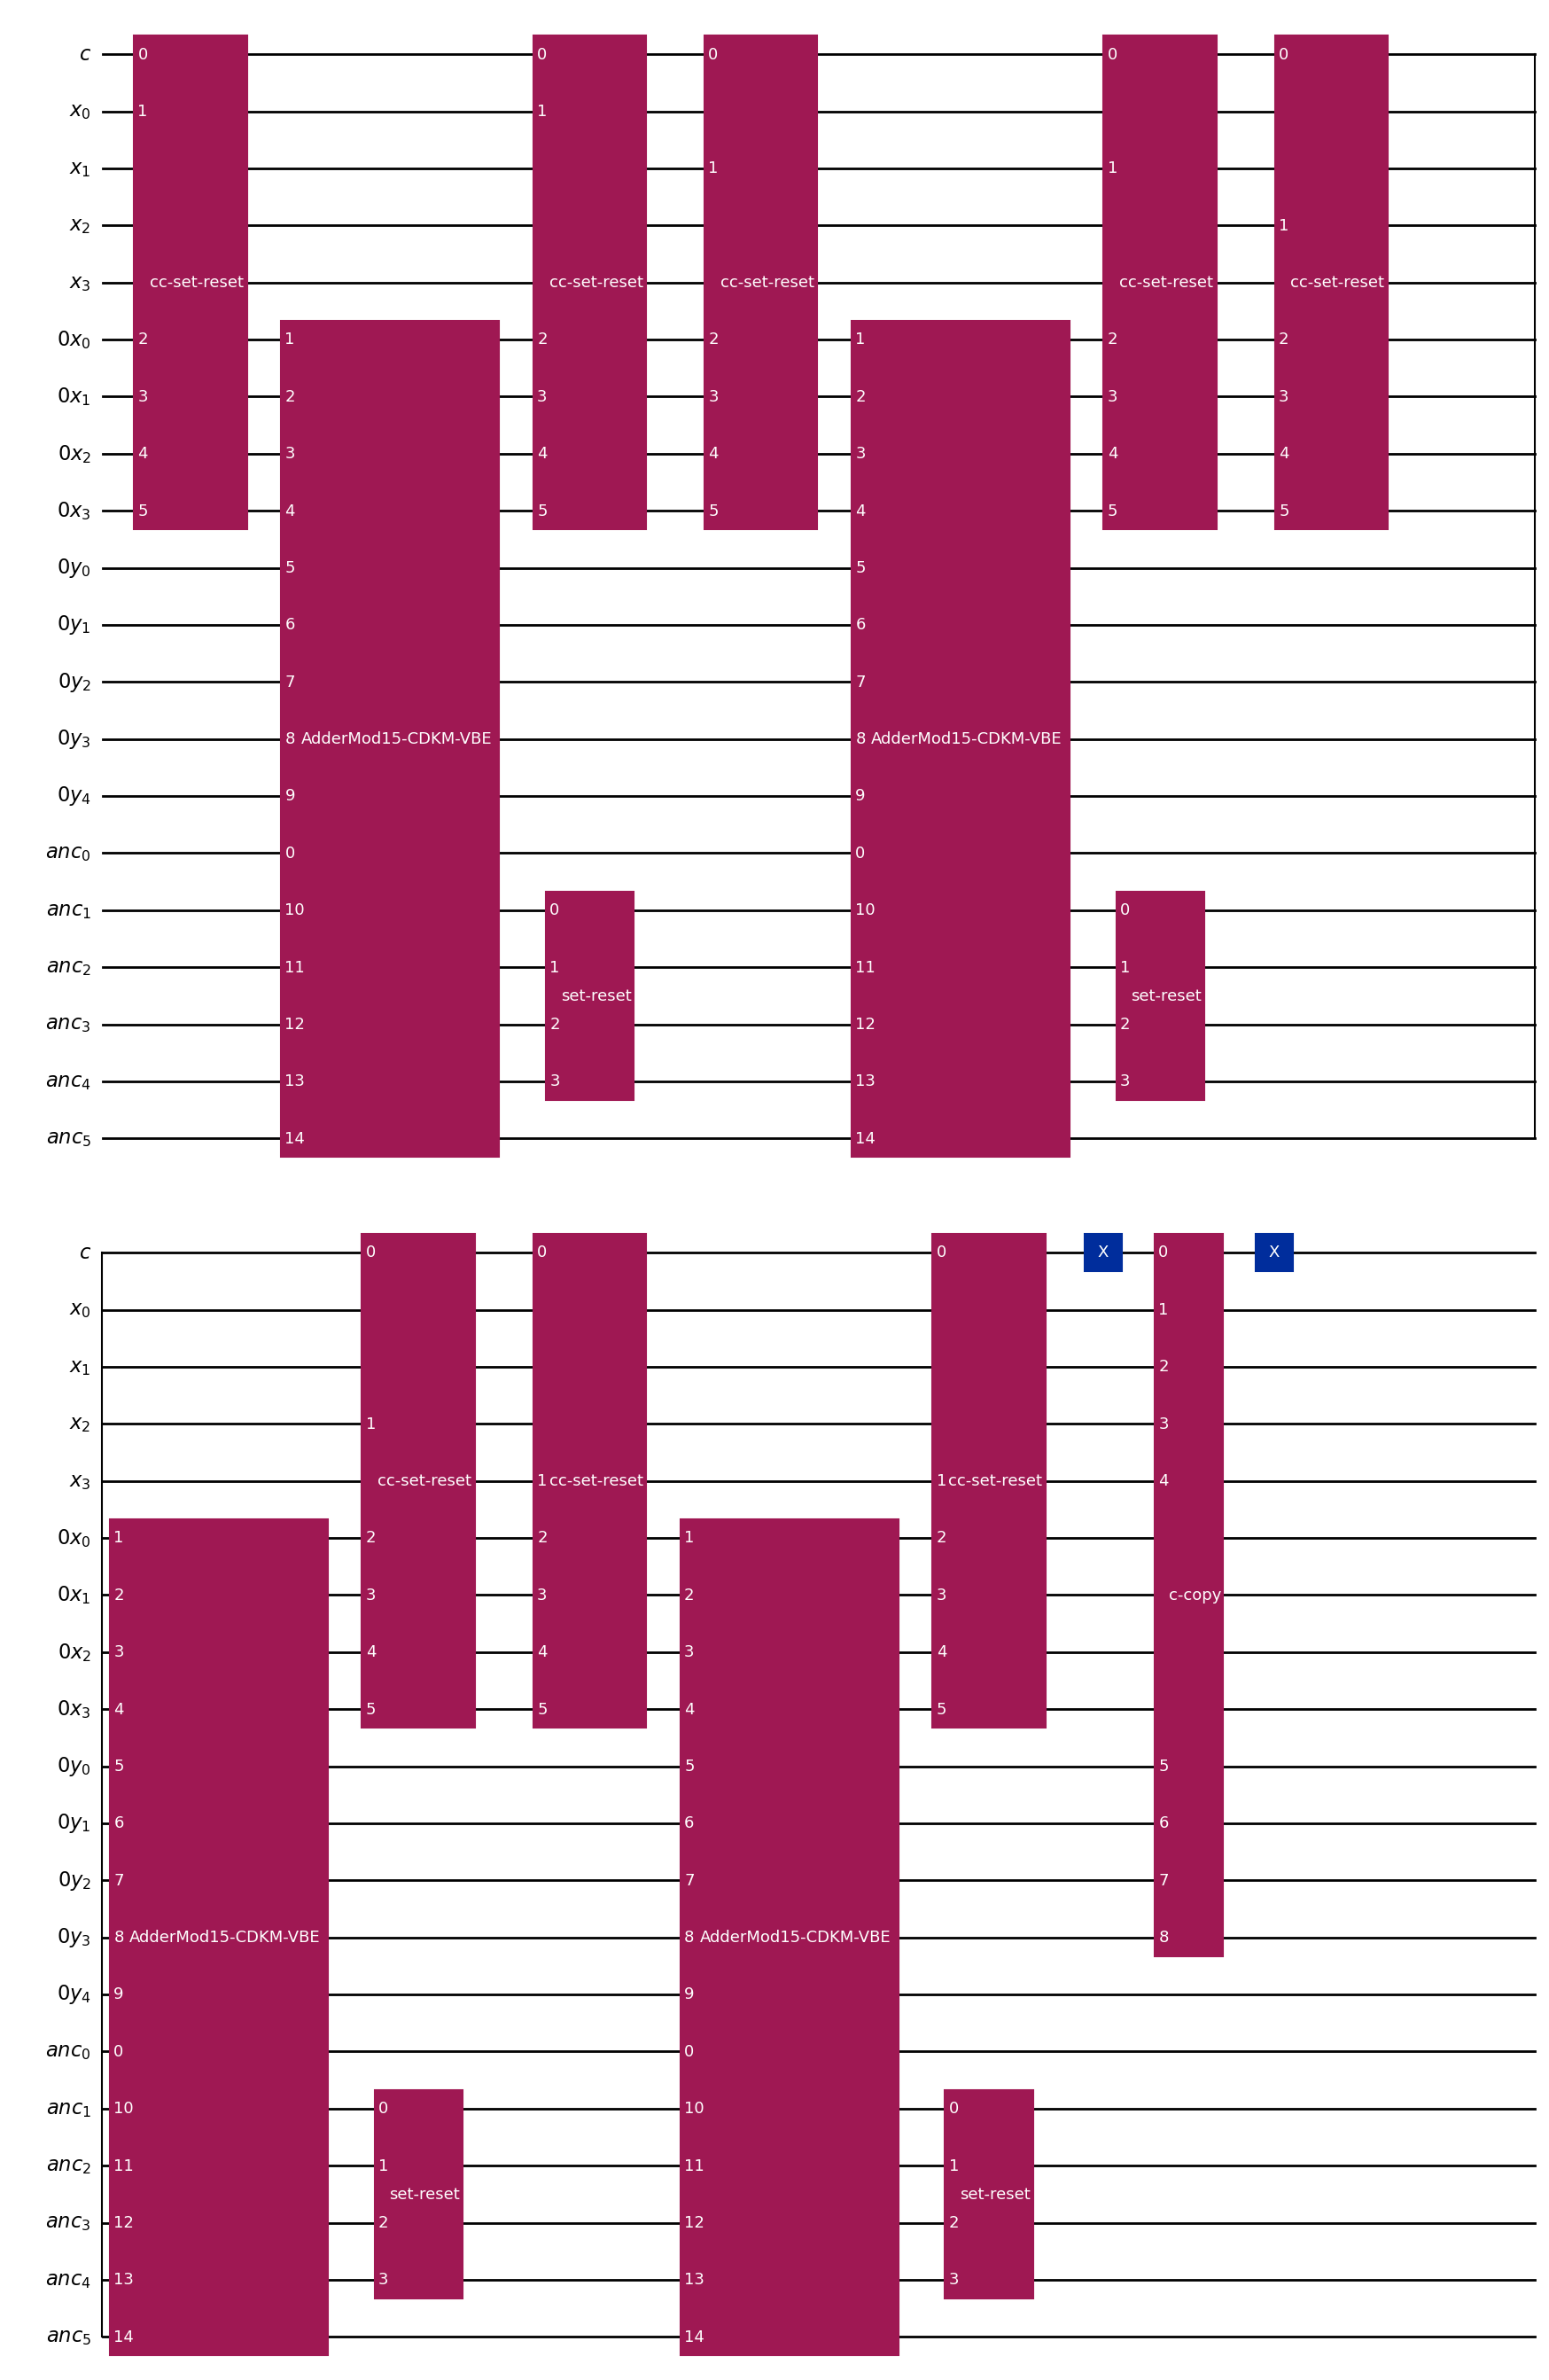

In [6]:
c_mult_mod_VBE(4,2,15).draw("mpl")

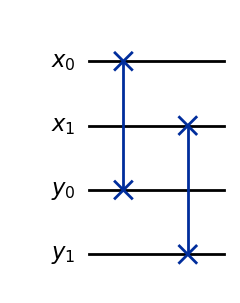

In [7]:
#swaps two registers
def swapper(num_qubits: int) -> QuantumCircuit:
    x = QuantumRegister(num_qubits, name="x")
    y = QuantumRegister(num_qubits, name="y")
    quantum_citcuit = QuantumCircuit(x,y)
    quantum_citcuit.name = "swapper"

    for i in range(num_qubits):
        quantum_citcuit.swap(x[i], y[i])
    return quantum_citcuit

swapper(2).draw("mpl")

In [8]:
def mod_inverse(base, exponent, mod):
    """Compute the modular inverse of base^(2^exponent) mod mod"""
    
    # Compute a^(2^i) using modular exponentiation
    value = pow(base, 2**exponent, mod)

    # Compute modular inverse using Extended Euclidean Algorithm
    def extended_gcd(a, b):
        if b == 0:
            return a, 1, 0
        g, x1, y1 = extended_gcd(b, a % b)
        return g, y1, x1 - (a // b) * y1
    
    g, inverse, _ = extended_gcd(value, mod)

    if g != 1:
        raise ValueError(f"No modular inverse exists for {value} mod {mod}")
    
    return inverse % mod

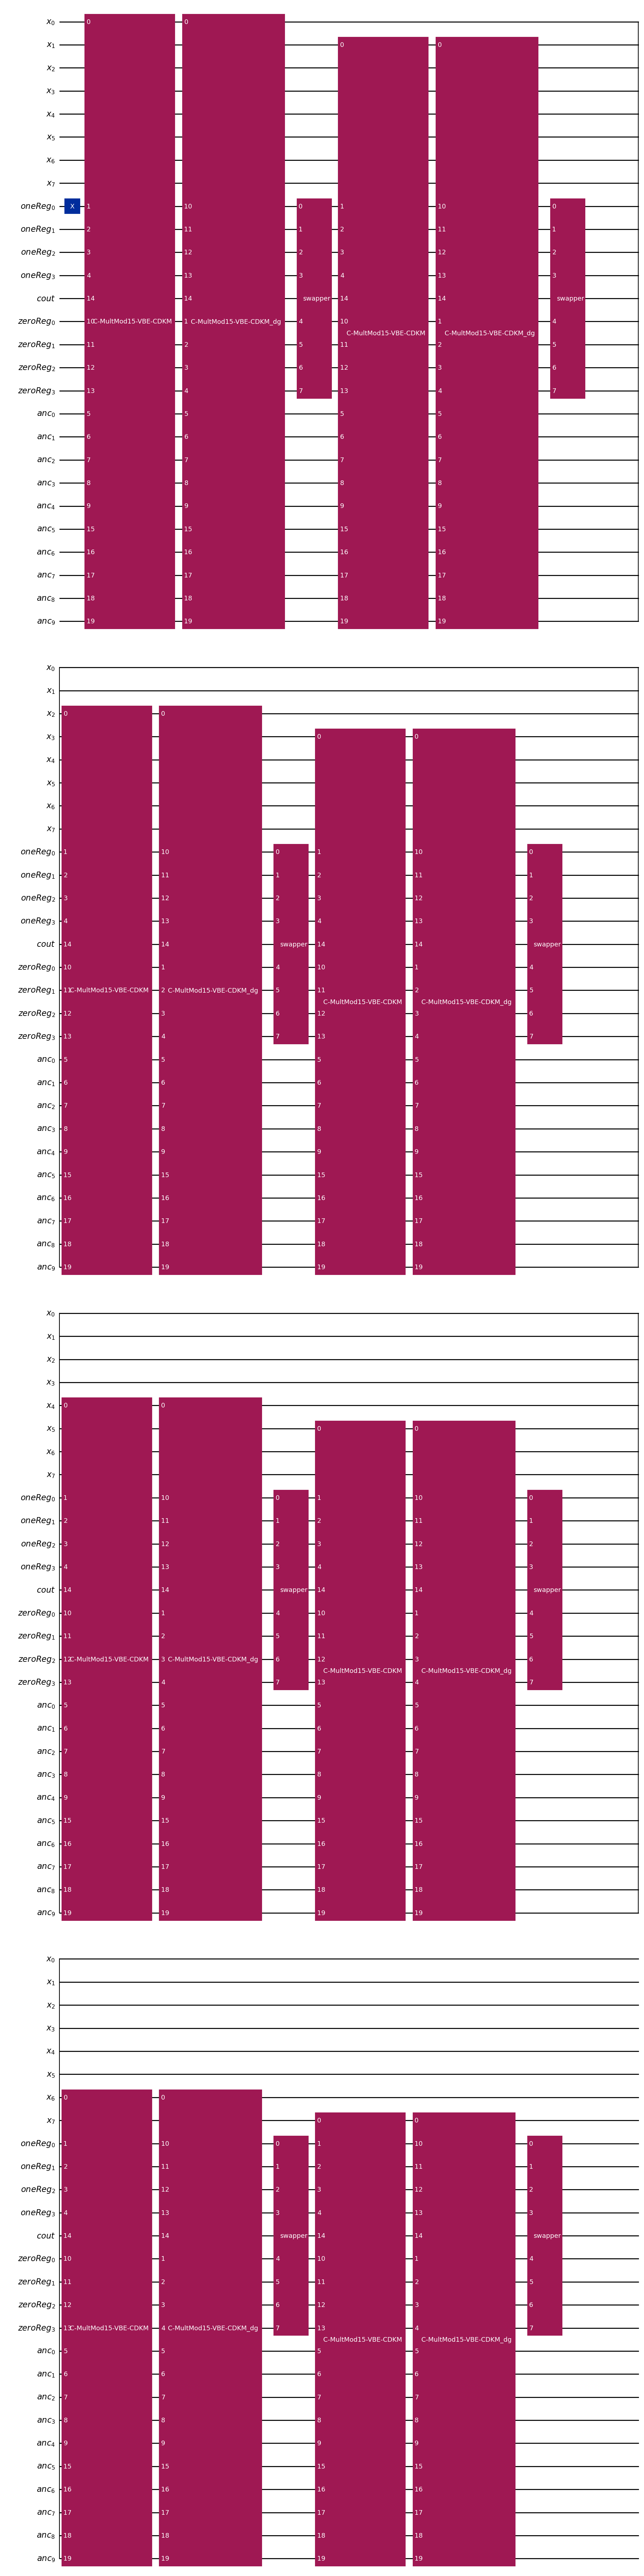

In [9]:
#a^x mod N
def exp_mod_VBE(num_qubits: int, a: int, N: int) -> QuantumCircuit:
    x = QuantumRegister(2*num_qubits, name="x")
    oneReg = QuantumRegister(num_qubits, name="oneReg")
    zeroReg = QuantumRegister(num_qubits, name="zeroReg")
    coutReg = QuantumRegister(1, name="cout")
    anc = AncillaRegister(2*num_qubits + 2, name="anc")
    quantum_circuit = QuantumCircuit(x, oneReg, coutReg, zeroReg, anc)
    quantum_circuit.name = f"ExpMod{N}-VBE"

    #init in 1
    quantum_circuit.x(oneReg[0])

    #perform c-mult-mod and inverse n-times
    for i in range(2*num_qubits):
        a2i = (a**(2**i))%N
        ia2i = mod_inverse(a, i, N)
        quantum_circuit.append(c_mult_mod_VBE(num_qubits, a2i, N), x[i:i+1] + oneReg[:] + anc[0:num_qubits+1] + zeroReg[:] + coutReg[:] + anc[num_qubits+1:])
        quantum_circuit.append(c_mult_mod_VBE(num_qubits, ia2i, N).inverse(), x[i:i+1] + zeroReg[:] + anc[0:num_qubits+1] + oneReg[:] + coutReg[:] + anc[num_qubits+1:])
        quantum_circuit.append(swapper(num_qubits), oneReg[:] + zeroReg[:])
    return quantum_circuit

exp_mod_VBE(4, 2, 15).draw("mpl")

In [10]:
from qiskit.quantum_info import Statevector

Statevector.from_label("0000000000000011").evolve(exp_mod_VBE(2, 1, 3)).draw("latex")

<IPython.core.display.Latex object>

In [11]:
n = 2
circ = exp_mod_VBE(n,2,3)
vectors = ["0"*(5*n) + "00" + format(i, f'0{2*n}b') for i in range(2**(2*n))]
#print(vectors[1])
#results = Statevector.from_label(vectors[-1]).evolve(circ)
results = []
for i in range(len(vectors)):
    results.append(Statevector.from_label(vectors[i]).evolve(circ))
#results.draw("latex")
print(results)

[Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)), Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0

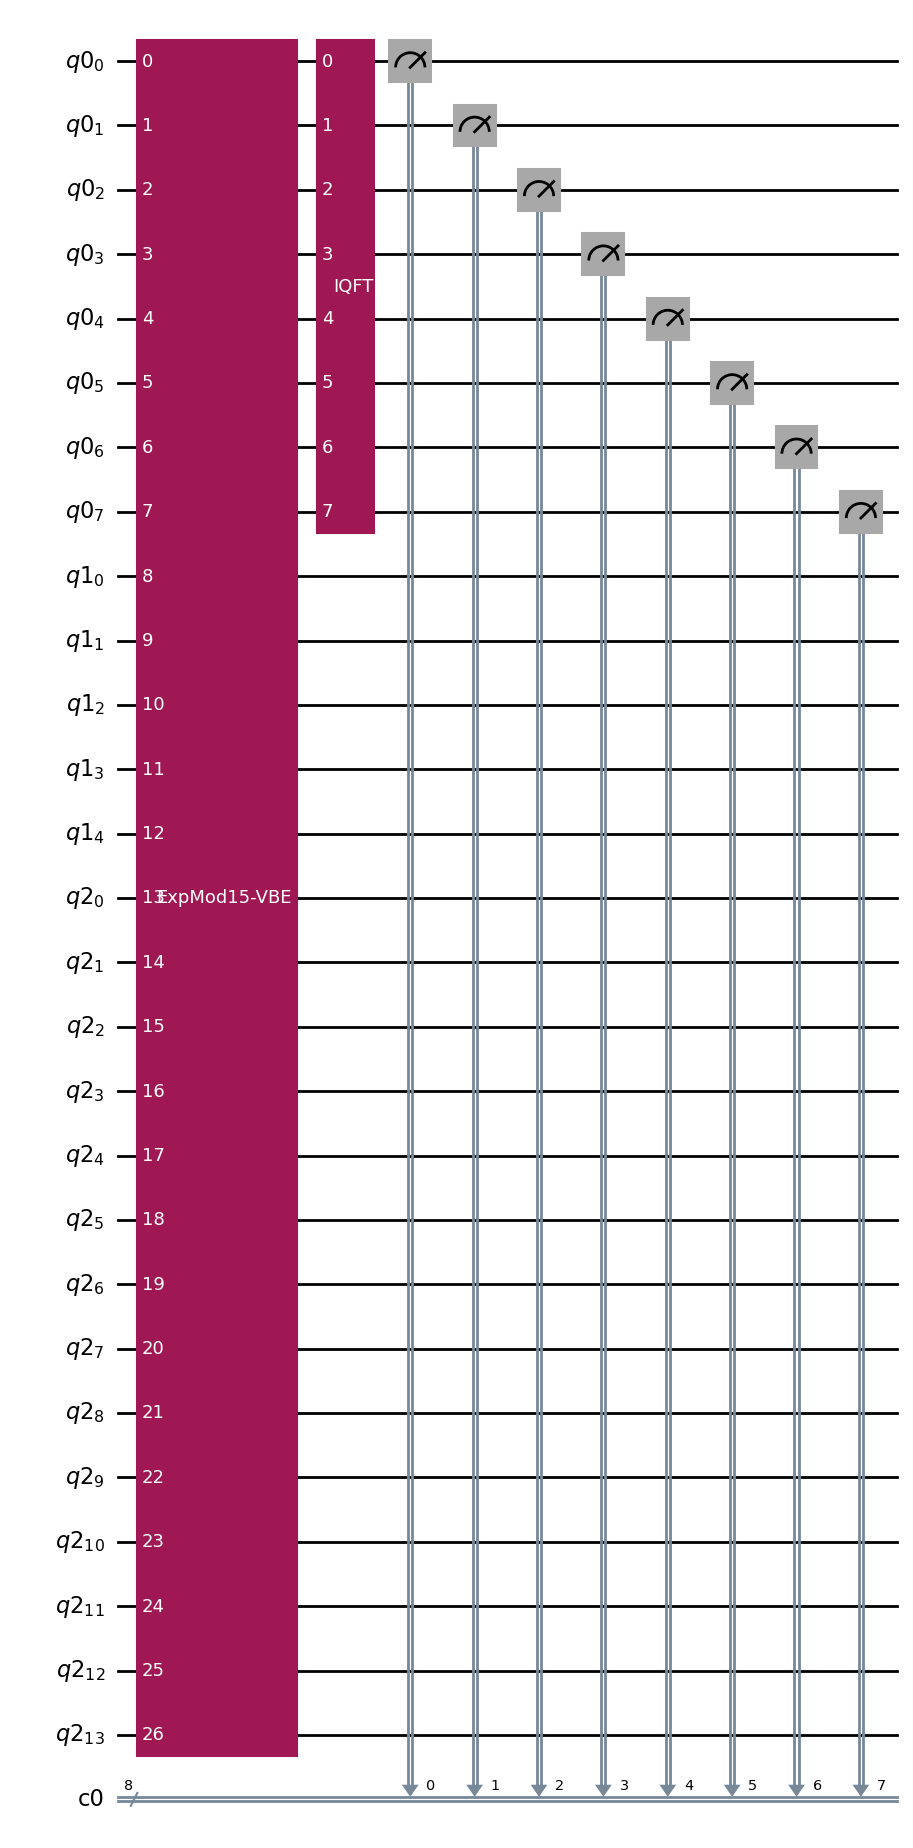

In [10]:
from math import log2
from qiskit.circuit.library import QFT
N = 15
n = int(log2(N)) + 1
reg_e = QuantumRegister(2*n)
reg_out = QuantumRegister(n+1)
reg_anc = QuantumRegister(3*n+2)
reg_class = ClassicalRegister(2*n)
qc = QuantumCircuit(reg_e, reg_out, reg_anc, reg_class)
qc.append(exp_mod_VBE(n, 2, N), reg_e[:] + reg_out[:] + reg_anc[:])
qc.append(QFT(2*n).inverse(), reg_e[:])
qc.measure(reg_e, reg_class)
qc.draw("mpl")

In [11]:
from qiskit_aer import AerSimulator

backend1 = AerSimulator()
backend1.set_max_qubits(30)
qc1 = transpile(qc, backend=backend1)

In [12]:
print(f"Circuit qubit count: {qc1.num_qubits}")
print(f"Circuit size: {qc1.size()}")
print(f"Circuit depth: {qc1.depth()}")

Circuit qubit count: 27
Circuit size: 8287
Circuit depth: 6681


In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler


sampler = Sampler(backend1)
job = sampler.run([qc1], shots=100)

counts = job.result()[0].data.reg_class.get_int_counts()